# Visual Localization

Given a 3D scene reconstructed by the feedforward pipeline, this notebook finds the camera pose of a held-out query image within the scene. Three stages: global frame retrieval via DINOv2-SALAD descriptors, local feature matching with **LoMa** (the dashboard-default matcher), and absolute pose estimation via PnP+RANSAC (pycolmap). XFeat and DISK are drop-in alternatives — see the final section.

In [1]:
%load_ext autoreload
%autoreload 2

## §1 — Load reconstruction

Load the precomputed `FeedforwardResult` from the zarr cache. The reconstruction holds 3D point positions, per-frame camera extrinsics and intrinsics, and the source image paths.

In [2]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyvista as pv
import torch

%matplotlib inline

from collab_splats.pointcloud.feedforward.base import FeedforwardResult
from collab_splats.localization import CameraLocalizer, LomaExtractor, plot_correspondences
from collab_splats.utils.visualization import create_camera_frustum_pyvista, pointcloud_to_polydata

# Static backend for headless (nbconvert) execution; interactive trame otherwise
pv.set_jupyter_backend("static" if os.environ.get("PYVISTA_OFF_SCREEN") else "trame")

Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/ti

In [3]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────
# Reconstruction produced by 02_pointcloud/feedforward_methods.ipynb (VGGT-Omega)
RECON = TUTORIAL_CACHE / "vggt_omega.zarr"
assert RECON.exists(), f"missing {RECON} — run 02_pointcloud/feedforward_methods.ipynb first"
print(f"RECON: {RECON}")

RECON: /workspace/outputs/tutorial_cache/2024_02_06/C0043/vggt_omega.zarr


In [4]:
# Load the pre-built reconstruction from the zarr cache
result = FeedforwardResult.load_zarr(RECON)
print(f"points: {result.points.shape}  frames: {result.extrinsics.shape[0]}")

points: (500000, 3)  frames: 30


## §2 — Hold out query frame

Select one frame as the query image and build a trimmed scene containing all remaining frames. The query's ground-truth extrinsic is retained for a consistency check at the end.

In [5]:
QUERY_IDX = 10

# Load query image (BGR → RGB) and its intrinsics from the reconstruction
query_bgr = cv2.imread(str(result.image_paths[QUERY_IDX]))
query_image = query_bgr[..., ::-1].copy()
query_K = result.intrinsics[QUERY_IDX]
ref_extrinsic = result.extrinsics[QUERY_IDX]  # kept for error check at §5

# Build trimmed scene — all frames except the query
keep = [i for i in range(len(result.image_paths)) if i != QUERY_IDX]


class _Trimmed:
    """Minimal scene container matching the FeedforwardResult interface."""

    points = result.points  # shared — 3D points are not frame-specific
    extrinsics = result.extrinsics[keep]
    intrinsics = result.intrinsics[keep]
    image_paths = [result.image_paths[i] for i in keep]


result_trimmed = _Trimmed()
print(f"Scene: {len(result_trimmed.image_paths)} reference frames, query held out at index {QUERY_IDX}")

Scene: 29 reference frames, query held out at index 10


## §3 — Localize query image

`CameraLocalizer.from_feedforward` indexes the reference frames. `localize` runs global retrieval → **LoMa** matching → PnP+RANSAC and returns a `LocalizationResult` with the estimated world-to-camera pose.

> **Note:** Index build extracts local features for every reference frame — a one-time cost per scene. LoMa weights auto-download on first use (~723 MB).

In [6]:
# Build localizer — indexes reference descriptors once (LoMa is the dashboard-default matcher)
localizer = CameraLocalizer.from_feedforward(result_trimmed, extractor=LomaExtractor())

# Run localization: retrieval → LoMa matching → PnP+RANSAC
loc = localizer.localize(query_image, query_K)
print(
    f"correspondences: {loc.n_correspondences}  inliers: {loc.n_inliers}  pose: {'found' if loc.pose is not None else 'FAILED'}"
)
if loc.pose is None:
    raise RuntimeError("Localization failed — check n_correspondences above. Try a different QUERY_IDX.")

Indexing frames:   0%|          | 0/29 [00:00<?, ?frame/s]

correspondences: 4414  inliers: 597  pose: found


## §4 — Correspondences

Visualize the 2D keypoint matches between the query image and the top retrieved reference frame. Inlier matches (green) survive RANSAC; outliers (red) are rejected.

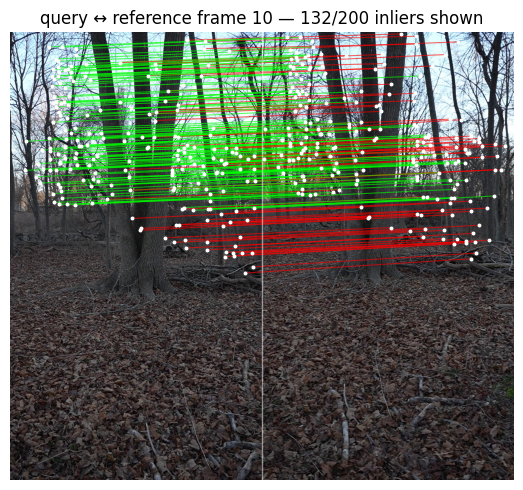

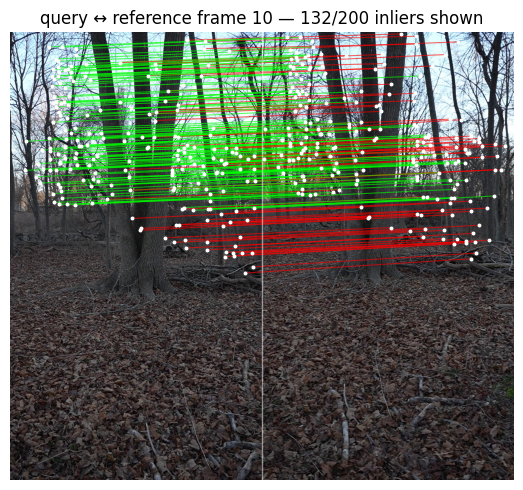

In [7]:
plot_correspondences(loc, query_image, result_trimmed.image_paths)

## §5 — 3D scene view

Render the reference camera frustums (grey) and the estimated query pose (red) in 3D. The query frustum should be visually consistent with the nearby reference frames.

2026-07-19 15:10:25.786 (  77.053s) [    74E61B306740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


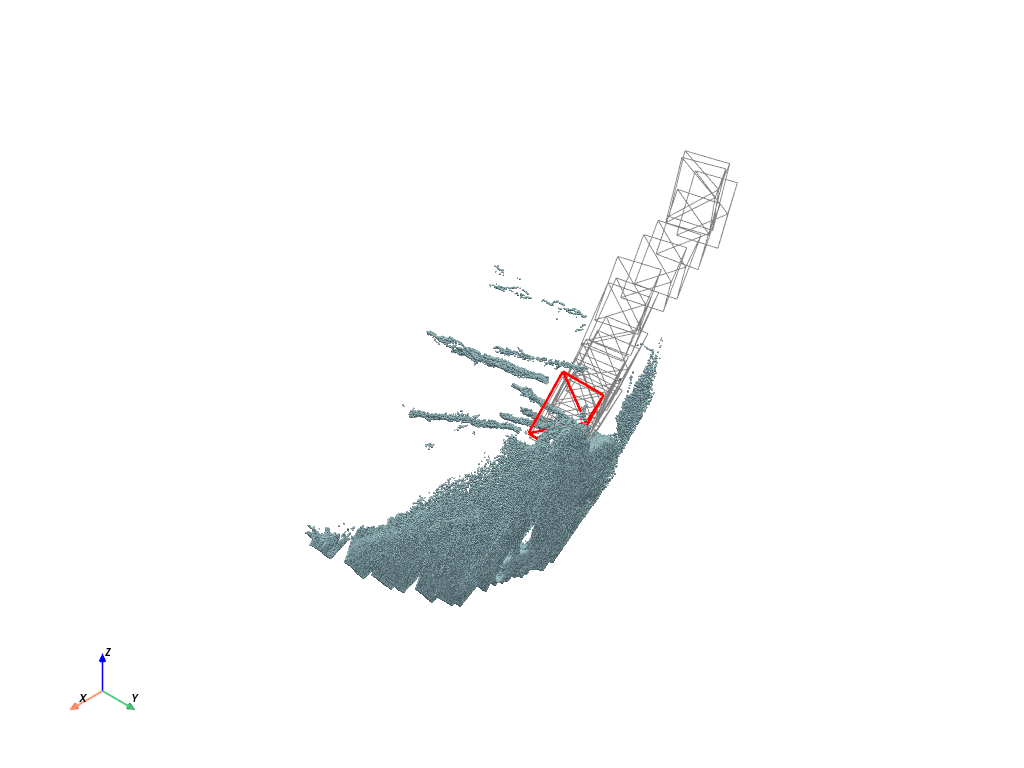

In [8]:
# Add point cloud and reference camera frustums
pl = pv.Plotter()
pl.add_mesh(pointcloud_to_polydata(result_trimmed.points), point_size=2, render_points_as_spheres=True)
for ext in result_trimmed.extrinsics:
    pl.add_mesh(create_camera_frustum_pyvista(np.linalg.inv(ext), scale=0.05), color="grey", line_width=1)

# Add localized query pose in red
pl.add_mesh(create_camera_frustum_pyvista(np.linalg.inv(loc.pose), scale=0.05), color="red", line_width=3)
pl.add_axes()
pl.show()

## §6 — Error metrics

Compute rotation and translation error against the feedforward reference extrinsic. This is a consistency check — the feedforward pose is not absolute ground truth but serves as a sanity bound.

In [9]:
# Compute geodesic rotation error and Euclidean translation error
R_est = loc.pose[:3, :3]
R_ref = ref_extrinsic[:3, :3]
rot_err_deg = np.degrees(np.arccos(np.clip((np.trace(R_est @ R_ref.T) - 1) / 2, -1, 1)))
t_err_cm = np.linalg.norm(loc.pose[:3, 3] - ref_extrinsic[:3, 3]) * 100

print(f"vs feedforward reference — rotation: {rot_err_deg:.2f}°  |  translation: {t_err_cm:.1f} cm")
print("(consistency check vs feedforward model — not absolute ground truth)")

vs feedforward reference — rotation: 6.24°  |  translation: 13.8 cm
(consistency check vs feedforward model — not absolute ground truth)


## Other matchers

Swap the extractor to change the local-matching frontend — retrieval, PnP, and everything else are unchanged:

- `XFeatExtractor()` — XFeat + LightGlue; lighter and faster, fewer correspondences
- `DiskExtractor()` — DISK + LightGlue
- `LomaGExtractor()` — LoMa-G, highest accuracy (larger weights, ~1.4 GB)

```python
from collab_splats.localization import XFeatExtractor

localizer = CameraLocalizer.from_feedforward(result_trimmed, extractor=XFeatExtractor())
loc = localizer.localize(query_image, query_K)
```